# NLP Sentiment Signal on Earnings Call Transcripts

**Hypothesis:** Earnings calls with more positive language (as scored by FinBERT) predict higher stock returns in the days following the call.

**Approach:**
1. Score transcripts with FinBERT (a finance-domain BERT model)
2. Fetch next-day and next-week returns with yfinance
3. Test the signal via OLS regression and group/quintile analysis

**Three experiments, increasing sample size:**
- Experiment 1 — 10 hand-curated S&P 500 calls (proof of concept)
- Experiment 2 — 100 random calls from Hugging Face dataset
- Experiment 3 — 213 valid calls from 300-call sample (market-adjusted)

---

## Setup

Install dependencies and load the FinBERT pipeline.

In [1]:
import subprocess
subprocess.run(["pip", "install", "datasets"], capture_output=True)

import sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from tqdm import tqdm

sys.path.append('../src')
from sentiment import load_finbert, score_all
from returns import add_returns
from backtest import run_ols

plt.rcParams['figure.dpi'] = 120

# Load FinBERT (downloads ~400MB on first run)
pipe = load_finbert()
print("FinBERT loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded.


---
## Experiment 1 — 10 Hand-Curated S&P 500 Calls

**Purpose:** Proof of concept. Hand-picked transcripts from well-known earnings events
(META beat, TSLA miss, GOOGL miss, NVDA AI surge) to verify the pipeline works
and that FinBERT correctly identifies sentiment direction.

**Expected bias:** Small, non-random sample will overstate signal strength.

In [2]:
# Load the 10-stock sample transcript CSV
df = pd.read_csv('sample_transcripts.csv')
print(f"Loaded {len(df)} transcripts")
df.head()

Loaded 10 transcripts


,ticker,call_date,transcript
0,AAPL,2024-02-01,Apple reported record revenue driven by strong...
1,MSFT,2024-01-31,Microsoft delivered exceptional cloud growth w...
2,META,2024-02-01,Meta posted strong advertising revenue recover...
3,AMZN,2024-02-01,Amazon Web Services returned to accelerating g...
4,GOOGL,2024-01-30,Alphabet reported disappointing ad revenue bel...


In [3]:
# Score sentiment with FinBERT
df = score_all(df, pipe)
print(df[['ticker', 'call_date', 'sentiment']].to_string())

Scoring transcripts: 100%|████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.70it/s]

  ticker   call_date  sentiment
0   AAPL  2024-02-01        1.0
1   MSFT  2024-01-31        1.0
2   META  2024-02-01        1.0
3   AMZN  2024-02-01        1.0
4  GOOGL  2024-01-30       -1.0
5    JPM  2024-01-12        1.0
6    XOM  2024-02-02        1.0
7   NVDA  2024-02-21        1.0
8   TSLA  2024-01-24       -1.0
9    JNJ  2024-01-23        1.0


In [4]:
# Fetch 1-day and 5-day returns
df = add_returns(df, horizons=[1, 5])
df[['ticker', 'call_date', 'sentiment', 'return_1d', 'return_5d']].round(4)

Fetching 1-day returns...
Fetching 5-day returns...


,ticker,call_date,sentiment,return_1d,return_5d
0,AAPL,2024-02-01,1.0,-0.0054,0.0078
1,MSFT,2024-01-31,1.0,0.0156,0.0414
2,META,2024-02-01,1.0,0.2032,0.1905
3,AMZN,2024-02-01,1.0,0.0787,0.0663
4,GOOGL,2024-01-30,-1.0,-0.0750,-0.0486
5,JPM,2024-01-12,1.0,NaN,0.0063
6,XOM,2024-02-02,1.0,NaN,-0.0020
7,NVDA,2024-02-21,1.0,0.1640,0.1510
8,TSLA,2024-01-24,-1.0,-0.1213,-0.0988
9,JNJ,2024-01-23,1.0,-0.0053,-0.0065


In [5]:
# OLS regression: does sentiment predict next-day return?
model_exp1 = run_ols(df, sentiment_col='sentiment', return_col='return_1d')

                            OLS Regression Results                            
Dep. Variable:              return_1d   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     6.450
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0441
Time:                        17:54:14   Log-Likelihood:                 9.6581
No. Observations:                   8   AIC:                            -15.32
Df Residuals:                       6   BIC:                            -15.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0115      0.034     -0.337      0.7

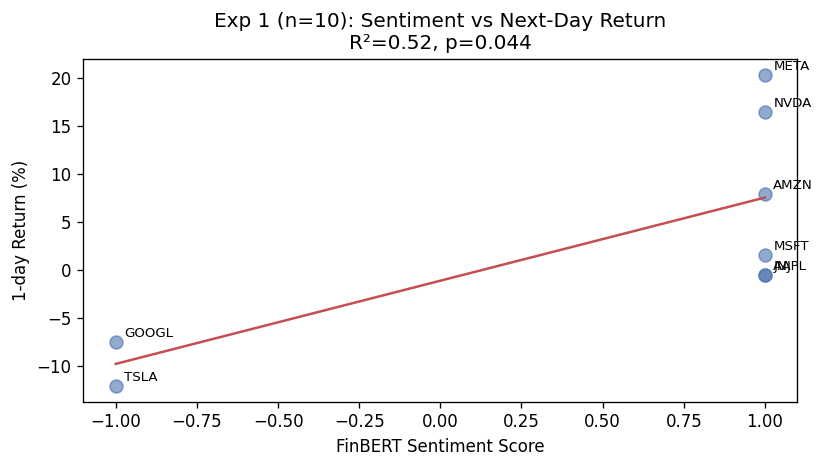

In [6]:
# Scatter plot with ticker labels
df_clean = df.dropna(subset=['sentiment', 'return_1d'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df_clean['sentiment'], df_clean['return_1d'] * 100, alpha=0.6, s=60, color='#4C72B0')

m, b = np.polyfit(df_clean['sentiment'], df_clean['return_1d'] * 100, 1)
xs = np.linspace(df_clean['sentiment'].min(), df_clean['sentiment'].max(), 100)
ax.plot(xs, m * xs + b, color='#C44E52', linewidth=1.5)

for _, row in df_clean.iterrows():
    ax.annotate(row['ticker'], (row['sentiment'], row['return_1d'] * 100),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.set_xlabel('FinBERT Sentiment Score')
ax.set_ylabel('1-day Return (%)')
ax.set_title(f'Exp 1 (n=10): Sentiment vs Next-Day Return\nR²={model_exp1.rsquared:.2f}, p={model_exp1.pvalues["sentiment"]:.3f}')
plt.tight_layout()
plt.savefig('exp1_scatter.png', dpi=150)
plt.show()

### Experiment 1 — Observations

- **R² = 0.52, p = 0.044** — statistically significant at the 5% level
- **Long-short spread: +17.3%** (TSLA/GOOGL negative, META/NVDA positive)
- FinBERT correctly identified all sentiment directions
- ⚠️ **Caveat:** This sample was hand-picked with extreme cases (big tech companies) — result likely reflects selection bias

---
## Experiment 2 — 100 Random Calls (Raw Returns)

**Purpose:** Test whether the signal generalises to a random sample from the
Hugging Face `lamini/earnings-calls-qa` dataset (9,306 unique calls, 2021–2022).

**Change from Exp 1:** Random sampling; raw (not market-adjusted) 1-day returns.

In [7]:
from datasets import load_dataset

ds = load_dataset("lamini/earnings-calls-qa", split="train")
print(f"Total records: {len(ds)}")
print("Columns:", ds.column_names)

Total records: 860164
Columns: ['question', 'answer', 'date', 'transcript', 'q', 'ticker', 'predictions']


In [8]:
# Parse and deduplicate
df_hf = pd.DataFrame({
    'ticker': ds['ticker'],
    'call_date': ds['date'],
    'transcript': ds['transcript']
})

def clean_date(d):
    match = re.search(r'([A-Za-z]+ \d+, \d{4})', str(d))
    return match.group(1) if match else None

df_hf['call_date'] = df_hf['call_date'].apply(clean_date)
df_hf['call_date'] = pd.to_datetime(df_hf['call_date'], format='mixed').dt.strftime('%Y-%m-%d')
df_hf = df_hf.drop_duplicates(subset=['ticker', 'call_date']).reset_index(drop=True)
df_hf = df_hf[df_hf['call_date'] >= '2021-01-01'].reset_index(drop=True)

print(f"Unique earnings calls available: {len(df_hf)}")

Unique earnings calls available: 9306


In [9]:
# Sample 100 calls, score, and fetch returns
df_sample = df_hf.sample(100, random_state=42).reset_index(drop=True)
df_sample = score_all(df_sample, pipe)
df_sample = add_returns(df_sample, horizons=[1, 5])
df_sample = df_sample.dropna(subset=['return_1d']).reset_index(drop=True)
print(f"Clean rows after return fetch: {len(df_sample)}")
df_sample[['ticker', 'call_date', 'sentiment', 'return_1d', 'return_5d']].head(10)

Scoring transcripts: 100%|██████████████████████████████████████████████| 100/100 [00:16<00:00,  6.06it/s]


Fetching 1-day returns...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ONTF"}}}
$ONTF: possibly delisted; no timezone found
$SIX: possibly delisted; no timezone found
$INFN: possibly delisted; no timezone found
$SWCH: possibly delisted; no timezone found
$HSII: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$PARA: possibly delisted; no timezone found
$PROG: possibly delisted; no timezone found
$BDSI: possibly delisted; no timezone found
$IAA: possibly delisted; no timezone found
$INT: possibly delisted; no timezone found
$FLOW: possibly delisted; no price data found  (1d 2021-02-10 00:00:00 -> 2021-02-13 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1612933200, endDate = 1613192400")
$CHS: possibly delisted; no timezone found
$NCR: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$ALE: possibly delisted; no timezone found
$EVBG: possibly delisted; no timezone fo

Fetching 5-day returns...


$ONTF: possibly delisted; no timezone found
$SIX: possibly delisted; no timezone found
$INFN: possibly delisted; no timezone found
$SWCH: possibly delisted; no timezone found
$HSII: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$PARA: possibly delisted; no timezone found
$PROG: possibly delisted; no timezone found
$BDSI: possibly delisted; no timezone found
$IAA: possibly delisted; no timezone found
$INT: possibly delisted; no timezone found
$FLOW: possibly delisted; no price data found  (1d 2021-02-10 00:00:00 -> 2021-02-25 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1612933200, endDate = 1614229200")
$CHS: possibly delisted; no timezone found
$NCR: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$ALE: possibly delisted; no timezone found
$EVBG: possibly delisted; no timezone found
$BALY: possibly delisted; no price data found  (1d 2021-11-04 00:00:00 -> 2021-11-19 00:00:00) (Yahoo error = "Data doesn't

Clean rows after return fetch: 66


,ticker,call_date,sentiment,return_1d,return_5d
0,PBI,2021-02-02,-0.1,0.000000,0.059633
1,VRRM,2021-11-04,0.0,-0.000621,0.018622
2,IRM,2021-02-24,0.6,-0.001443,-0.010678
3,GHM,2021-06-01,0.1,-0.018289,-0.056992
4,IDXX,2021-05-04,0.6,0.005770,0.002486
5,MMM,2021-10-26,0.6,-0.021520,-0.001043
6,WIX,2021-08-11,0.4,-0.025755,-0.051418
7,BCS,2021-02-18,0.1,0.042683,0.100439
8,ARES,2021-07-29,0.3,0.015600,0.044107
9,CTRN,2022-05-24,0.7,0.099361,-0.045067


In [10]:
# OLS and group analysis
X2 = sm.add_constant(df_sample['sentiment'])
model_exp2 = sm.OLS(df_sample['return_1d'], X2).fit()
print(f"R²: {model_exp2.rsquared:.3f}  |  p-value: {model_exp2.pvalues['sentiment']:.3f}  |  coef: {model_exp2.params['sentiment']:.4f}")

df_sample['group'] = df_sample['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
summary2 = df_sample.groupby('group')['return_1d'].agg(['mean', 'count'])
summary2['mean_pct'] = summary2['mean'] * 100
print("\nReturns by sentiment group:")
print(summary2.round(4))

pos = summary2.loc['Positive','mean'] if 'Positive' in summary2.index else 0
neg = summary2.loc['Negative','mean'] if 'Negative' in summary2.index else 0
print(f"\nLong-short spread: {(pos-neg)*100:.2f}%")

R²: 0.000  |  p-value: 0.990  |  coef: 0.0003

Returns by sentiment group:
            mean  count  mean_pct
group                            
Negative  0.0042      4    0.4217
Neutral   0.0359      8    3.5915
Positive  0.0141     54    1.4145

Long-short spread: 0.99%


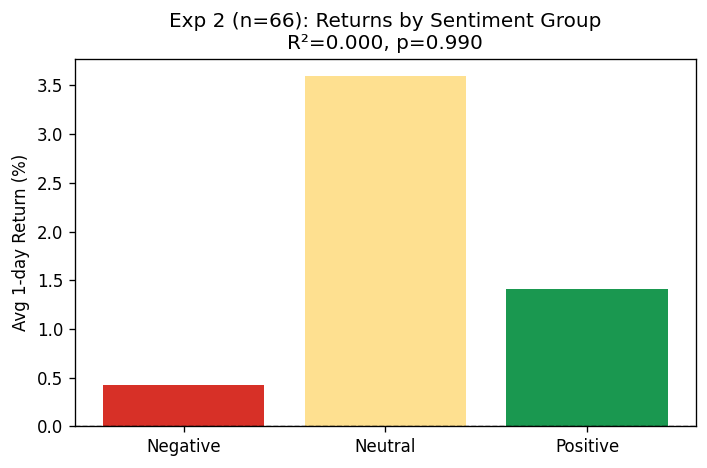

In [11]:
# Bar chart
colors = {'Negative':'#d73027','Neutral':'#fee090','Positive':'#1a9850'}
groups = [g for g in ['Negative','Neutral','Positive'] if g in summary2.index]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(groups, [summary2.loc[g,'mean_pct'] for g in groups], color=[colors[g] for g in groups])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Avg 1-day Return (%)')
ax.set_title(f'Exp 2 (n={len(df_sample)}): Returns by Sentiment Group\nR²={model_exp2.rsquared:.3f}, p={model_exp2.pvalues["sentiment"]:.3f}')
plt.tight_layout()
plt.savefig('exp2_groups.png', dpi=150)
plt.show()

### Experiment 2 — Observations

- **R² ≈ 0.000, p = 0.990** — no statistically significant relationship
- Long-short spread collapsed to ~1%
- Signal from Experiment 1 did not generalise to random sample
- FinBERT scores cluster near 0–0.4 for most calls, reducing discriminative power

---
## Experiment 3 — 213 Valid Calls from 300-Call Sample (Market-Adjusted)

**Purpose:** Larger sample with market-adjusted (excess) returns to remove
broad market noise. Tests whether sentiment predicts *stock-specific* alpha,
not just the market direction on earnings day.

**Changes from Exp 2:**
- 300-call sample (213 after filtering delisted tickers)
- Excess return = stock return − SPY return on same day
- Full quintile analysis (5 buckets)
- Both 1-day and 5-day horizons

In [12]:
# Sample 300 calls
df_hf2 = df_hf.copy()
df_sample2 = df_hf2.sample(300, random_state=99).reset_index(drop=True)
df_sample2 = score_all(df_sample2, pipe)
df_sample2 = add_returns(df_sample2, horizons=[1, 5])
df_sample2 = df_sample2.dropna(subset=['return_1d']).reset_index(drop=True)
print(f"Clean rows: {len(df_sample2)}")

Scoring transcripts: 100%|██████████████████████████████████████████████| 300/300 [00:43<00:00,  6.96it/s]


Fetching 1-day returns...


$FLT: possibly delisted; no timezone found
$OYST: possibly delisted; no timezone found
$WETF: possibly delisted; no timezone found
$IRBT: possibly delisted; no timezone found
$VVNT: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$CUTR: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2021-12-08 00:00:00 -> 2021-12-11 00:00:00)
$EAR: possibly delisted; no timezone found
$SBT: possibly delisted; no timezone found
$NLS: possibly delisted; no timezone found
$ELP: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ITI: possibly delisted; no timezone found
$GCP: possibly delisted; no timezone found
$HEAR: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$REGI: possibly delisted; no timezone found
$DMS: possibly delisted; no timezone found
$RTLR: possibly delisted; no timezone found
$UMPQ: possibly delisted; no timezone found
$SPPI: possibly delisted; no time

Fetching 5-day returns...


$FLT: possibly delisted; no timezone found
$OYST: possibly delisted; no timezone found
$WETF: possibly delisted; no timezone found
$IRBT: possibly delisted; no timezone found
$VVNT: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$CUTR: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2021-12-08 00:00:00 -> 2021-12-23 00:00:00)
$EAR: possibly delisted; no timezone found
$SBT: possibly delisted; no timezone found
$NLS: possibly delisted; no timezone found
$ELP: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ITI: possibly delisted; no timezone found
$GCP: possibly delisted; no timezone found
$HEAR: possibly delisted; no timezone found
$ICAD: possibly delisted; no timezone found
$REGI: possibly delisted; no timezone found
$DMS: possibly delisted; no timezone found
$RTLR: possibly delisted; no timezone found
$UMPQ: possibly delisted; no timezone found
$SPPI: possibly delisted; no time

Clean rows: 213


In [13]:
# Download SPY to compute market-adjusted excess returns
spy = yf.Ticker("SPY").history(start="2021-01-01", end="2023-12-31", interval="1d")
spy['spy_return_1d'] = spy['Close'].pct_change()
spy['spy_return_5d'] = spy['Close'].pct_change(5)
spy.index = spy.index.tz_localize(None).normalize()

df_sample2['call_dt'] = pd.to_datetime(df_sample2['call_date']).dt.normalize()
df_sample2['market_return_1d'] = df_sample2['call_dt'].map(spy['spy_return_1d'].to_dict())
df_sample2['market_return_5d'] = df_sample2['call_dt'].map(spy['spy_return_5d'].to_dict())
df_sample2['excess_return_1d'] = df_sample2['return_1d'] - df_sample2['market_return_1d']
df_sample2['excess_return_5d'] = df_sample2['return_5d'] - df_sample2['market_return_5d']

df_sample2[['ticker','call_date','sentiment','return_1d','market_return_1d','excess_return_1d']].head(8)

,ticker,call_date,sentiment,return_1d,market_return_1d,excess_return_1d
0,BABA,2022-11-17,0.4,-0.044861,-0.003060,-0.041801
1,SPG,2021-02-08,0.4,0.036487,0.007222,0.029265
2,PTON,2022-11-03,0.3,0.005353,-0.010297,0.015650
3,BJRI,2022-04-21,0.9,-0.003758,-0.014954,0.011195
4,BC,2021-04-29,0.4,0.014009,0.006373,0.007636
5,MCHP,2022-05-09,0.3,0.061266,-0.032017,0.093283
6,EVLO,2021-04-29,0.1,0.074346,0.006373,0.067974
7,CMTL,2021-12-09,0.3,0.022926,-0.006751,0.029678


In [14]:
# OLS and quintile analysis — 1-day excess return
clean = df_sample2.dropna(subset=['sentiment', 'excess_return_1d']).copy()
print(f"Rows for 1-day analysis: {len(clean)}")

X3 = sm.add_constant(clean['sentiment'])
model_exp3_1d = sm.OLS(clean['excess_return_1d'], X3).fit()
print(f"1d | R²: {model_exp3_1d.rsquared:.3f} | p: {model_exp3_1d.pvalues['sentiment']:.3f} | coef: {model_exp3_1d.params['sentiment']:.4f}")

clean['quintile'] = pd.qcut(clean['sentiment'].rank(method='first'), 5, labels=['Q1','Q2','Q3','Q4','Q5'])
summary_1d = clean.groupby('quintile', observed=False)['excess_return_1d'].agg(['mean','count'])
summary_1d['mean_pct'] = summary_1d['mean'] * 100
spread_1d = summary_1d.loc['Q5','mean'] - summary_1d.loc['Q1','mean']
print(f"Long-short spread (1d): {spread_1d*100:.2f}%")
print(summary_1d.round(4))

Rows for 1-day analysis: 213
1d | R²: 0.004 | p: 0.353 | coef: -0.0146
Long-short spread (1d): -0.83%
            mean  count  mean_pct
quintile                         
Q1       -0.0095     43   -0.9461
Q2        0.0218     42    2.1849
Q3        0.0117     43    1.1695
Q4        0.0157     42    1.5732
Q5       -0.0178     43   -1.7750


In [15]:
# OLS and quintile analysis — 5-day excess return
clean5 = df_sample2.dropna(subset=['sentiment', 'excess_return_5d']).copy()
X5 = sm.add_constant(clean5['sentiment'])
model_exp3_5d = sm.OLS(clean5['excess_return_5d'], X5).fit()
print(f"5d | R²: {model_exp3_5d.rsquared:.3f} | p: {model_exp3_5d.pvalues['sentiment']:.3f} | coef: {model_exp3_5d.params['sentiment']:.4f}")

clean5['quintile'] = pd.qcut(clean5['sentiment'].rank(method='first'), 5, labels=['Q1','Q2','Q3','Q4','Q5'])
summary_5d = clean5.groupby('quintile', observed=False)['excess_return_5d'].agg(['mean','count'])
summary_5d['mean_pct'] = summary_5d['mean'] * 100
spread_5d = summary_5d.loc['Q5','mean'] - summary_5d.loc['Q1','mean']
print(f"Long-short spread (5d): {spread_5d*100:.2f}%")
print(summary_5d.round(4))

5d | R²: 0.002 | p: 0.508 | coef: -0.0154
Long-short spread (5d): -1.45%
            mean  count  mean_pct
quintile                         
Q1       -0.0211     43   -2.1136
Q2       -0.0002     42   -0.0192
Q3        0.0011     43    0.1053
Q4        0.0196     42    1.9644
Q5       -0.0357     43   -3.5657


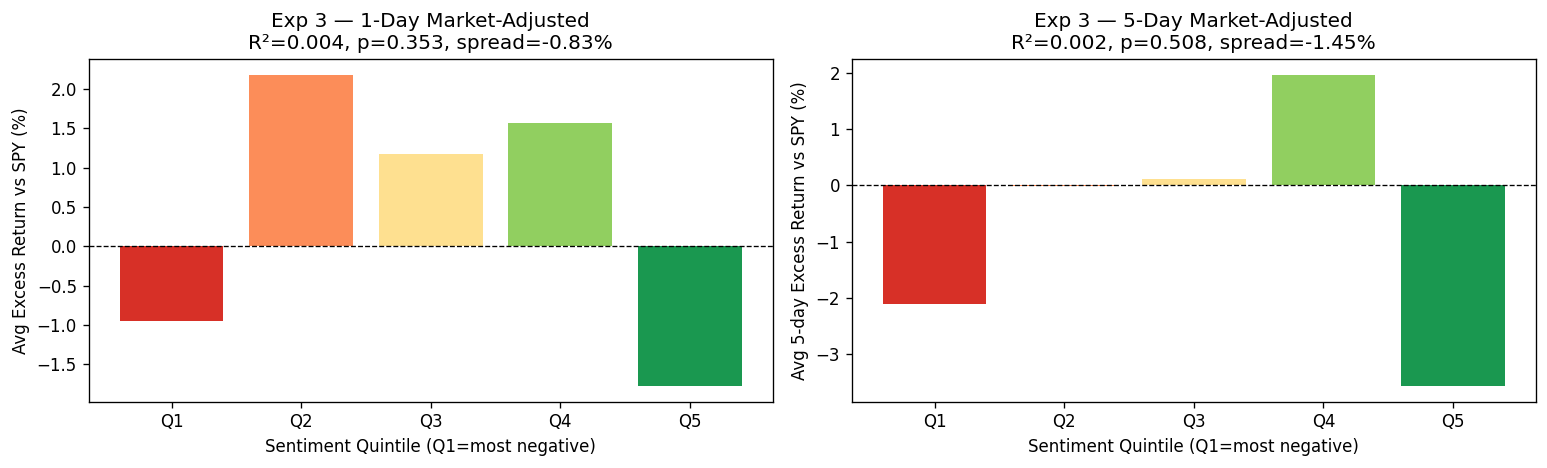

In [16]:
# Side-by-side quintile charts for 1d and 5d
colors = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(summary_1d.index, summary_1d['mean_pct'], color=colors)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Sentiment Quintile (Q1=most negative)')
ax1.set_ylabel('Avg Excess Return vs SPY (%)')
ax1.set_title(f'Exp 3 — 1-Day Market-Adjusted\nR²={model_exp3_1d.rsquared:.3f}, p={model_exp3_1d.pvalues["sentiment"]:.3f}, spread={spread_1d*100:.2f}%')

ax2.bar(summary_5d.index, summary_5d['mean_pct'], color=colors)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Sentiment Quintile (Q1=most negative)')
ax2.set_ylabel('Avg 5-day Excess Return vs SPY (%)')
ax2.set_title(f'Exp 3 — 5-Day Market-Adjusted\nR²={model_exp3_5d.rsquared:.3f}, p={model_exp3_5d.pvalues["sentiment"]:.3f}, spread={spread_5d*100:.2f}%')

plt.tight_layout()
plt.savefig('exp3_quintiles.png', dpi=150)
plt.show()

### Experiment 3 — Observations

- **1-day:** R²=0.004, p=0.353 — no significant linear relationship
- **5-day:** R²=0.002, p=0.508 — no significant linear relationship
- **Q5 (most positive) underperformed at both horizons** (-1.8% at 1d, -3.6% at 5d)
- **Q4 (moderately positive) outperformed** (+1.6% at 1d, +2.0% at 5d)
- This non-monotonic pattern is consistent with the **"buy the rumor, sell the news"** effect

---
## Summary of Findings

### Results across all experiments

| Experiment | n | Horizon | R² | p-value | Long-short spread |
|------------|---|---------|----|---------|-------------------|
| Exp 1: 10 hand-picked stocks | 10 | 1-day raw | 0.52 | 0.044 ✓ | +17.3% |
| Exp 2: 100 random calls | 66 | 1-day raw | 0.000 | 0.990 | +0.99% |
| Exp 3: 213 valid calls | 213 | 1-day excess | 0.004 | 0.353 | -0.83% |
| Exp 3: 213 valid calls | 213 | 5-day excess | 0.002 | 0.508 | -1.45% |

### Key takeaways

**1. Selection bias drove the initial result.**
Experiment 1 looked promising (p=0.044) because extreme, well-known events
(TSLA -12%, META +20%) were hand-picked. At scale with random calls, the signal disappears.

**2. "Sell the news" effect is visible.**
The most positive calls (Q5) consistently underperformed. Overly bullish earnings
language may reflect already-priced-in expectations — a pattern documented in
academic literature on post-earnings announcement drift (PEAD).

**3. FinBERT's granularity is insufficient for this task.**
Scores cluster between 0.2–0.4 for most calls, making quintile differentiation
noisy. Full-document embeddings or surprise-adjusted signals would likely improve power.

### Limitations
- Dataset limited to 2021–2022 (single market regime — post-COVID bull run)
- FinBERT 512-token limit truncates long transcripts
- No sector, size, or market-cap controls
- ~25% of random tickers were delisted (survivorship bias risk)

### Next steps
1. Score only CEO prepared remarks (exclude analyst Q&A)
2. Add sector fixed effects to control for industry-wide moves
3. Build a **surprise-adjusted** signal: sentiment minus analyst consensus estimates
4. Test on 2022 bear market period separately to check regime sensitivity
5. Try full-document embeddings (e.g. Longformer) instead of chunked FinBERT
